In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML

In [17]:
!wget -nc https://hgdownload.cse.ucsc.edu/goldenpath/hg19/encodeDCC/wgEncodeAwgSegmentation/wgEncodeAwgSegmentationChromhmmHelas3.bed.gz

File ‘wgEncodeAwgSegmentationChromhmmHelas3.bed.gz’ already there; not retrieving.



In [18]:
filename = 'wgEncodeAwgSegmentationChromhmmHelas3.bed.gz'
df = pd.read_csv(filename, sep='\t', header=None, compression='gzip')
df.columns = ['chrom', 'start', 'end', 'state', 'score', 'strand',
              'thickStart', 'thickEnd', 'itemRgb']

# Map state names to functional groups (based on UCSC documentation)
state_to_group = {
    # Bright Red: Active Promoter
    'Tss':   'Active Promoter',
    'TssF':  'Active Promoter',
    # Light Red: Promoter Flanking
    'PromF': 'Promoter Flanking',
    # Purple: Inactive Promoter
    'PromP': 'Inactive Promoter',
    # Orange: Candidate Strong enhancer
    'Enh':   'Candidate Strong enhancer',
    'EnhF':  'Candidate Strong enhancer',
    # Yellow: Candidate Weak enhancer/DNase
    'EnhWF': 'Candidate Weak enhancer/DNase',
    'EnhW':  'Candidate Weak enhancer/DNase',
    'DNaseU':'Candidate Weak enhancer/DNase',
    'DNaseD':'Candidate Weak enhancer/DNase',
    'FaireW':'Candidate Weak enhancer/DNase',
    # Blue: Distal CTCF/Candidate Insulator
    'CtrcfO':'Distal CTCF/Candidate Insulator',
    'Ctcf':  'Distal CTCF/Candidate Insulator',
    # Dark Green: Transcription associated
    "Gen5'": 'Transcription associated',
    'Elon':  'Transcription associated',
    'ElonW': 'Transcription associated',
    "Gen3'": 'Transcription associated',
    'Pol2':  'Transcription associated',
    'H4K20': 'Transcription associated',
    # Light Green: Low activity proximal to active states
    'Low':   'Low activity proximal to active states',
    # Gray: Polycomb repressed
    'ReprD': 'Polycomb repressed',
    'Repr':  'Polycomb repressed',
    'ReprW': 'Polycomb repressed',
    # Light Gray: Heterochromatin/Repetitive/Copy Number Variation
    'Quies': 'Heterochromatin/Repetitive/Copy Number Variation',
    'Art':   'Heterochromatin/Repetitive/Copy Number Variation'
}

# Apply the mapping (default to 'Unknown' if state not found)
df['functional_group'] = df['state'].map(state_to_group).fillna('Unknown')

#Create a colored bar using the RGB values from itemRgb
def color_bar_from_rgb(rgb_str):
    # rgb_str is like "225,225,225"
    return f'<span style="display:inline-block; width:16px; height:16px; background-color:rgb({rgb_str}); border:1px solid gray;"></span>'

df['color_bar'] = df['itemRgb'].apply(color_bar_from_rgb)

#Display the first 20 rows
display_cols = ['chrom', 'start', 'end', 'state', 'functional_group', 'color_bar']
HTML(df.head(20)[display_cols].to_html(escape=False))

,chrom,start,end,state,functional_group,color_bar
0,chr1,0,10200,Quies,Heterochromatin/Repetitive/Copy Number Variation,
1,chr1,10200,10400,DnaseU,Unknown,
2,chr1,10400,15800,Low,Low activity proximal to active states,
3,chr1,15800,16000,FaireW,Candidate Weak enhancer/DNase,
4,chr1,16000,16600,Art,Heterochromatin/Repetitive/Copy Number Variation,
5,chr1,16600,54400,Quies,Heterochromatin/Repetitive/Copy Number Variation,
6,chr1,54400,54800,Repr,Polycomb repressed,
7,chr1,54800,56800,ReprW,Polycomb repressed,
8,chr1,56800,58000,Quies,Heterochromatin/Repetitive/Copy Number Variation,
9,chr1,58000,60600,Low,Low activity proximal to active states,


In [19]:
file_path = '/content/ontargetraw.xlsx'

# Load only the sheet named 'HeLa'
df_hela = pd.read_excel(file_path, sheet_name='hela')

# Display first 5 rows to verify structure
df_hela.head()

,Chromosome,Start,End,Strand,sgRNA,Normalized efficacy
0,chr4,184605984,184606006,-,ACATCAGGTTACCTCTACCAAGG,0.177011
1,chr1,11736866,11736888,+,CTGATGCCAGCTAGTGGGCGAGG,0.001588
2,chr4,25379067,25379089,+,CTGTTTCCCATCCTTCCGGGTGG,0.498712
3,chr12,57936737,57936759,-,AATGTATGCACAGGGAACAGAGG,0.114708
4,chr2,131103494,131103516,-,CCAGACTCACCCGCTTGCCCAGG,0.250399


In [20]:
df_chrom = df
df_grna = df_hela

print("df_chrom columns:", df_chrom.columns.tolist())
print("df_grna columns:", df_grna.columns.tolist())

print(f"df_chrom rows: {len(df_chrom)}")
print(f"df_grna rows: {len(df_grna)}")

df_chrom columns: ['chrom', 'start', 'end', 'state', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'functional_group', 'color_bar']
df_grna columns: ['Chromosome', 'Start', 'End', 'Strand', 'sgRNA', 'Normalized efficacy']
df_chrom rows: 1421299
df_grna rows: 8101


In [21]:

# Build dictionary for fast lookup per chromosome
chrom_dfs = {}
for chrom in df_chrom['chrom'].unique():
    sub = df_chrom[df_chrom['chrom'] == chrom].sort_values('start').reset_index(drop=True)
    chrom_dfs[chrom] = sub

def fast_lookup(chrom, pos_1based):
    """Return (state, functional_group, itemRgb) for bin containing 1‑based position."""
    if chrom not in chrom_dfs:
        return 'unknown', 'unknown', '0,0,0'
    sub = chrom_dfs[chrom]
    pos0 = pos_1based - 1   # 1‑based → 0‑based conversion
    idx = sub['start'].searchsorted(pos0, side='right') - 1
    if idx >= 0 and sub.iloc[idx]['end'] > pos0:
        row = sub.iloc[idx]
        return row['state'], row['functional_group'], row['itemRgb']
    return 'unknown', 'unknown', '0,0,0'

# Apply to all gRNAs
results = df_grna.apply(lambda r: pd.Series(fast_lookup(r['Chromosome'], r['Start'])), axis=1)
df_grna[['chrom_state', 'functional_group', 'itemRgb']] = results

# Save merged CSV (no HTML color_bar)
df_grna.to_csv('gRNA_chromatin_merged.csv', index=False)

In [22]:
# Load the merged CSV
df_merged = pd.read_csv('gRNA_chromatin_merged.csv')

# Display first 10 rows with relevant columns
print("First 10 rows:")
print(df_merged[['Chromosome', 'Start', 'End', 'Strand', 'sgRNA',
                 'Normalized efficacy', 'chrom_state', 'functional_group', 'itemRgb']].head(10))

# Also show a random sample of 5 rows
print("\nRandom sample of 5 rows:")
print(df_merged[['Chromosome', 'Start', 'Normalized efficacy', 'chrom_state', 'functional_group']].sample(5))

First 10 rows:
  Chromosome      Start        End Strand                    sgRNA  \
0       chr4  184605984  184606006      -  ACATCAGGTTACCTCTACCAAGG   
1       chr1   11736866   11736888      +  CTGATGCCAGCTAGTGGGCGAGG   
2       chr4   25379067   25379089      +  CTGTTTCCCATCCTTCCGGGTGG   
3      chr12   57936737   57936759      -  AATGTATGCACAGGGAACAGAGG   
4       chr2  131103494  131103516      -  CCAGACTCACCCGCTTGCCCAGG   
5      chr19   13044456   13044478      +  CATCAGACGCCTCCAGCCGCCGG   
6      chr11   62568644   62568666      -  CCTTGAACTTGAGCAACAACAGG   
7       chrX   70764460   70764482      -  GGCTTCTTCCAAGCGACCCAGGG   
8      chr11   67161213   67161235      -  GCACGAGGCTGGGTCGAAGACGG   
9      chr20    5099445    5099467      -  ACTAAGGGCCGAAGATAACGCGG   

   Normalized efficacy chrom_state  \
0             0.177011       Quies   
1             0.001588        Ctcf   
2             0.498712         Tss   
3             0.114708        Elon   
4             0.250399  

In [23]:
df = pd.read_csv('gRNA_chromatin_merged.csv')
print(df.head())
print(df['chrom_state'].value_counts())

  Chromosome      Start        End Strand                    sgRNA  \
0       chr4  184605984  184606006      -  ACATCAGGTTACCTCTACCAAGG   
1       chr1   11736866   11736888      +  CTGATGCCAGCTAGTGGGCGAGG   
2       chr4   25379067   25379089      +  CTGTTTCCCATCCTTCCGGGTGG   
3      chr12   57936737   57936759      -  AATGTATGCACAGGGAACAGAGG   
4       chr2  131103494  131103516      -  CCAGACTCACCCGCTTGCCCAGG   

   Normalized efficacy chrom_state  \
0             0.177011       Quies   
1             0.001588        Ctcf   
2             0.498712         Tss   
3             0.114708        Elon   
4             0.250399         Low   

                                   functional_group      itemRgb  
0  Heterochromatin/Repetitive/Copy Number Variation  225,225,225  
1                   Distal CTCF/Candidate Insulator   10,190,254  
2                                   Active Promoter      255,0,0  
3                          Transcription associated     0,176,80  
4            Lo

In [24]:
# Check the functional_group column
print("Unique functional groups:")
print(df['functional_group'].unique())
print("\nData type:", df['functional_group'].dtype)
print("\nAre there any NaNs?", df['functional_group'].isna().sum())
print("\nRows with 'unknown':", (df['functional_group'] == 'unknown').sum())

# Drop rows where functional_group is NaN or 'unknown'
df_clean = df[~df['functional_group'].isin(['unknown', np.nan])].copy()
print("\nRemaining rows:", len(df_clean))

# Now try dummy encoding again
dummies = pd.get_dummies(df_clean['functional_group'], drop_first=True)
print("\nDummies shape:", dummies.shape)
print("Dummies columns:", dummies.columns.tolist())

# Ensure all dummy columns are numeric
X = sm.add_constant(dummies.astype(float))
y = df_clean['Normalized efficacy'].astype(float)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

Unique functional groups:
['Heterochromatin/Repetitive/Copy Number Variation'
 'Distal CTCF/Candidate Insulator' 'Active Promoter'
 'Transcription associated' 'Low activity proximal to active states'
 'Unknown' 'Candidate Weak enhancer/DNase' 'Promoter Flanking'
 'Inactive Promoter' 'Candidate Strong enhancer' 'Polycomb repressed']

Data type: object

Are there any NaNs? 0

Rows with 'unknown': 0

Remaining rows: 8101

Dummies shape: (8101, 10)
Dummies columns: ['Candidate Strong enhancer', 'Candidate Weak enhancer/DNase', 'Distal CTCF/Candidate Insulator', 'Heterochromatin/Repetitive/Copy Number Variation', 'Inactive Promoter', 'Low activity proximal to active states', 'Polycomb repressed', 'Promoter Flanking', 'Transcription associated', 'Unknown']
                             OLS Regression Results                            
Dep. Variable:     Normalized efficacy   R-squared:                       0.006
Model:                             OLS   Adj. R-squared:                  0.005

In [25]:
# If not already built, rebuild chrom_dfs dictionary for fast lookup
chrom_dfs = {}
for chrom in df_chrom['chrom'].unique():
    sub = df_chrom[df_chrom['chrom'] == chrom].sort_values('start').reset_index(drop=True)
    chrom_dfs[chrom] = sub

def proportion_active_in_window(chrom, pos_1based, window_bp=1000):
    """Return fraction of active bases in [pos_1based - window_bp, pos_1based + window_bp]."""
    if chrom not in chrom_dfs:
        return np.nan
    pos0 = pos_1based - 1
    win_start = pos0 - window_bp
    win_end = pos0 + window_bp
    sub = chrom_dfs[chrom]
    overlapping = sub[(sub['start'] < win_end) & (sub['end'] > win_start)]
    if len(overlapping) == 0:
        return np.nan
    active_groups = ['Active Promoter', 'Candidate Strong enhancer', 'Candidate Weak enhancer/DNase']
    total_active_bp = 0
    for _, seg in overlapping.iterrows():
        seg_start = max(seg['start'], win_start)
        seg_end = min(seg['end'], win_end)
        seg_len = seg_end - seg_start
        if seg['functional_group'] in active_groups:
            total_active_bp += seg_len
    total_window_bp = 2 * window_bp
    return total_active_bp / total_window_bp

# If df_grna already has the merged columns, you can still use it; just ensure coordinates are there.
df_grna['prop_active_1kb'] = df_grna.apply(
    lambda r: proportion_active_in_window(r['Chromosome'], r['Start']), axis=1
)

# Check basic stats
print(df_grna['prop_active_1kb'].describe())

count    8101.000000
mean        0.254374
std         0.401039
min         0.000000
25%         0.000000
50%         0.000000
75%         0.594500
max         1.000000
Name: prop_active_1kb, dtype: float64


In [26]:
print(df_grna.columns.tolist())
print(df_chrom.columns.tolist())

['Chromosome', 'Start', 'End', 'Strand', 'sgRNA', 'Normalized efficacy', 'chrom_state', 'functional_group', 'itemRgb', 'prop_active_1kb']
['chrom', 'start', 'end', 'state', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'functional_group', 'color_bar']


                             OLS Regression Results                            
Dep. Variable:     Normalized efficacy   R-squared:                       0.004
Model:                             OLS   Adj. R-squared:                  0.004
Method:                  Least Squares   F-statistic:                     36.53
Date:                 Wed, 22 Apr 2026   Prob (F-statistic):           1.57e-09
Time:                         19:27:35   Log-Likelihood:                 2321.7
No. Observations:                 8101   AIC:                            -4639.
Df Residuals:                     8099   BIC:                            -4625.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2492      

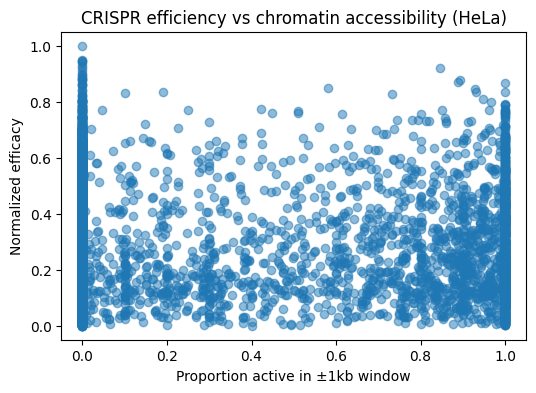

In [27]:
# Ensure no missing values
df_clean = df_grna.dropna(subset=['prop_active_1kb', 'Normalized efficacy']).copy()

X = sm.add_constant(df_clean['prop_active_1kb'])
y = df_clean['Normalized efficacy']
model_cont = sm.OLS(y, X).fit()
print(model_cont.summary())

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_clean['prop_active_1kb'], y, alpha=0.5)
plt.xlabel('Proportion active in ±1kb window')
plt.ylabel('Normalized efficacy')
plt.title('CRISPR efficiency vs chromatin accessibility (HeLa)')
plt.show()

In [28]:
# Load merged data (or use df_grna if it has chrom_state)
df = pd.read_csv('gRNA_chromatin_merged.csv')

# Drop rows with missing chrom_state
df = df.dropna(subset=['chrom_state', 'Normalized efficacy'])

# One-hot encode the 25 states (there may be fewer than 25 in your data)
dummies = pd.get_dummies(df['chrom_state'], drop_first=True)
X = sm.add_constant(dummies.astype(float))
y = df['Normalized efficacy'].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Normalized efficacy   R-squared:                       0.008
Model:                             OLS   Adj. R-squared:                  0.005
Method:                  Least Squares   F-statistic:                     2.817
Date:                 Wed, 22 Apr 2026   Prob (F-statistic):           8.01e-06
Time:                         19:27:35   Log-Likelihood:                 2335.8
No. Observations:                 8101   AIC:                            -4624.
Df Residuals:                     8077   BIC:                            -4456.
Df Model:                           23                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2163      0.030      7.14

/tmp/ipykernel_25102/4069508607.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='functional_group', x='Normalized efficacy',


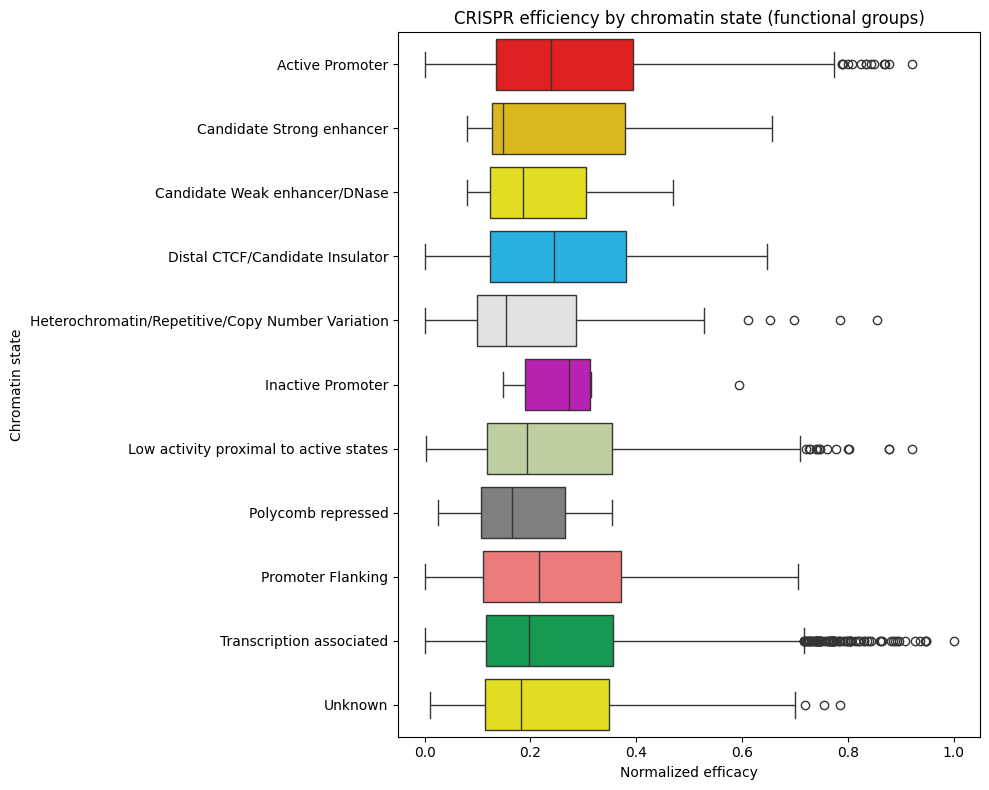

In [29]:
import seaborn as sns

df = df_grna.dropna(subset=['functional_group', 'Normalized efficacy'])

# Get one representative RGB per functional_group
color_map_raw = df.groupby('functional_group')['itemRgb'].first().to_dict()
color_map_norm = {}
for group, rgb_str in color_map_raw.items():
    rgb = [int(x)/255.0 for x in rgb_str.split(',')]
    color_map_norm[group] = rgb

# Sort groups (optional: order by median efficacy)
groups = sorted(df['functional_group'].unique())
palette = [color_map_norm[g] for g in groups]

# Horizontal boxplot (groups on y, efficacy on x)
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, y='functional_group', x='Normalized efficacy',
            order=groups, palette=palette, orient='h')
plt.xlabel('Normalized efficacy')
plt.ylabel('Chromatin state')
plt.title('CRISPR efficiency by chromatin state (functional groups)')
plt.tight_layout()
plt.show()

In [35]:
# Step 1: Install pyfaidx
!pip install pyfaidx

# Step 2: Import libraries
import pandas as pd
from pyfaidx import Fasta

# Step 3: Load your merged CSV
df = pd.read_csv('gRNA_chromatin_merged.csv')

# Step 4: Identify which chromosomes you need
chromosomes_needed = df['Chromosome'].unique()
print("Chromosomes needed:", chromosomes_needed)

# Step 5: Download only those chromosome FASTA files from UCSC
for chrom in chromosomes_needed:
    !wget -nc http://hgdownload.cse.ucsc.edu/goldenPath/hg19/chromosomes/{chrom}.fa.gz

# Step 6: Unpack all .fa.gz files
!gunzip -f *.fa.gz

# Step 7: Combine the chromosome files into a single file (use a temporary name to avoid self-inclusion)
!cat chr*.fa > hg19_combined_temp.fa

# Step 8: Rename to final name
!mv hg19_combined_temp.fa hg19_subset.fa

# Step 9: Remove individual chromosome files to save space
!rm -f chr*.fa

# Step 10: Load genome (pyfaidx creates index automatically)
genome = Fasta('hg19_subset.fa')

# Step 11: Function to extract target sequence
def get_target_sequence(chrom, start_1based, end_1based, strand):
    start0 = start_1based - 1  # convert to 0‑based
    try:
        seq = genome[chrom][start0:end_1based]
        if strand == '-':
            seq = seq.reverse.complement
        return str(seq).upper()
    except Exception as e:
        print(f"Error for {chrom}:{start_1based}-{end_1based} {strand}: {e}")
        return None

# Step 12: Apply to DataFrame (test on first few rows first)
# Test on first 5 rows
for idx, row in df.head(5).iterrows():
    target = get_target_sequence(row['Chromosome'], row['Start'], row['End'], row['Strand'])
    print(f"Row {idx}: target sequence = {target}")

Chromosomes needed: ['chr4' 'chr1' 'chr12' 'chr2' 'chr19' 'chr11' 'chrX' 'chr20' 'chr17'
 'chr3' 'chr5' 'chr7' 'chr16' 'chr9' 'chr6' 'chr13' 'chr15' 'chr22'
 'chr14' 'chr8' 'chr10' 'chr21' 'chr18']
--2026-04-22 19:40:43--  http://hgdownload.cse.ucsc.edu/goldenPath/hg19/chromosomes/chr4.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61700369 (59M) [application/x-gzip]
Saving to: ‘chr4.fa.gz’

chr4.fa.gz          100%[===================>]  58.84M  32.0MB/s    in 1.8s    

2026-04-22 19:40:45 (32.0 MB/s) - ‘chr4.fa.gz’ saved [61700369/61700369]

--2026-04-22 19:40:46--  http://hgdownload.cse.ucsc.edu/goldenPath/hg19/chromosomes/chr1.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:80..

In [37]:
# Compute Hamming distances for first 1000 rows

def hamming_distance(seq1, seq2):
    if seq1 is None or seq2 is None:
        return None
    s1 = seq1.upper().replace('U', 'T')
    s2 = seq2.upper()
    if len(s1) != len(s2):
        return None
    return sum(a != b for a, b in zip(s1, s2))

# Take first 1000 rows
df_sub = df.head(1000).copy()

# Extract target sequences
df_sub['target_seq'] = df_sub.apply(
    lambda r: get_target_sequence(r['Chromosome'], r['Start'], r['End'], r['Strand']),
    axis=1
)

# Compute Hamming distances
df_sub['hamming'] = df_sub.apply(
    lambda r: hamming_distance(r['sgRNA'], r['target_seq']),
    axis=1
)

# Display results
print("Hamming distance distribution (first 1000 rows):")
print(df_sub['hamming'].value_counts(dropna=False))

print("\nRows with mismatches (Hamming > 0):")
mismatches = df_sub[df_sub['hamming'] > 0]
if len(mismatches) > 0:
    print(mismatches[['Chromosome', 'Start', 'sgRNA', 'target_seq', 'hamming']].head(10))
else:
    print("No mismatches found in the first 1000 rows.")

# Save subset to CSV
df_sub.to_csv('gRNA_first1000_with_targets.csv', index=False)
print("\nSaved first 1000 rows to 'gRNA_first1000_with_targets.csv'")

Hamming distance distribution (first 1000 rows):
hamming
0    1000
Name: count, dtype: int64

Rows with mismatches (Hamming > 0):
No mismatches found in the first 1000 rows.

Saved first 1000 rows to 'gRNA_first1000_with_targets.csv'


In [38]:

display_cols = ['sgRNA', 'target_seq', 'hamming']
print(df_sub[display_cols].head(20))  # first 20 rows

# Or show all rows where Hamming > 0 (mismatches)
mismatches = df_sub[df_sub['hamming'] > 0]
if not mismatches.empty:
    print("\nRows with mismatches:")
    print(mismatches[display_cols])
else:
    print("\nNo mismatches found in the first 1000 rows.")

                      sgRNA               target_seq  hamming
0   ACATCAGGTTACCTCTACCAAGG  ACATCAGGTTACCTCTACCAAGG        0
1   CTGATGCCAGCTAGTGGGCGAGG  CTGATGCCAGCTAGTGGGCGAGG        0
2   CTGTTTCCCATCCTTCCGGGTGG  CTGTTTCCCATCCTTCCGGGTGG        0
3   AATGTATGCACAGGGAACAGAGG  AATGTATGCACAGGGAACAGAGG        0
4   CCAGACTCACCCGCTTGCCCAGG  CCAGACTCACCCGCTTGCCCAGG        0
5   CATCAGACGCCTCCAGCCGCCGG  CATCAGACGCCTCCAGCCGCCGG        0
6   CCTTGAACTTGAGCAACAACAGG  CCTTGAACTTGAGCAACAACAGG        0
7   GGCTTCTTCCAAGCGACCCAGGG  GGCTTCTTCCAAGCGACCCAGGG        0
8   GCACGAGGCTGGGTCGAAGACGG  GCACGAGGCTGGGTCGAAGACGG        0
9   ACTAAGGGCCGAAGATAACGCGG  ACTAAGGGCCGAAGATAACGCGG        0
10  GAGGTTCTGTGGGCACAACGTGG  GAGGTTCTGTGGGCACAACGTGG        0
11  CATAGAACCAGTCCAACACAGGG  CATAGAACCAGTCCAACACAGGG        0
12  GGATGCCACACTTCAGAAGCAGG  GGATGCCACACTTCAGAAGCAGG        0
13  GCCCTTGAGGGTGCCACGAAGGG  GCCCTTGAGGGTGCCACGAAGGG        0
14  CTGATGATGAGGACCGACAGAGG  CTGATGATGAGGACCGACAGAGG        0
15  TCCA

In [39]:
# Display a side-by-side comparison of sgRNA and target_seq for first 10 rows
print("Hand inspection of sgRNA vs target_seq (first 10 rows):")
print("-" * 80)

# Select relevant columns for display
inspect_cols = ['Chromosome', 'Start', 'Strand', 'sgRNA', 'target_seq', 'hamming']
for idx, row in df_sub.head(10).iterrows():
    print(f"Row {idx}: {row['Chromosome']}:{row['Start']} ({row['Strand']})")
    print(f"  sgRNA     : {row['sgRNA']}")
    print(f"  target_seq: {row['target_seq']}")
    print(f"  Hamming   : {row['hamming']}")
    print("-" * 40)

Hand inspection of sgRNA vs target_seq (first 10 rows):
--------------------------------------------------------------------------------
Row 0: chr4:184605984 (-)
  sgRNA     : ACATCAGGTTACCTCTACCAAGG
  target_seq: ACATCAGGTTACCTCTACCAAGG
  Hamming   : 0
----------------------------------------
Row 1: chr1:11736866 (+)
  sgRNA     : CTGATGCCAGCTAGTGGGCGAGG
  target_seq: CTGATGCCAGCTAGTGGGCGAGG
  Hamming   : 0
----------------------------------------
Row 2: chr4:25379067 (+)
  sgRNA     : CTGTTTCCCATCCTTCCGGGTGG
  target_seq: CTGTTTCCCATCCTTCCGGGTGG
  Hamming   : 0
----------------------------------------
Row 3: chr12:57936737 (-)
  sgRNA     : AATGTATGCACAGGGAACAGAGG
  target_seq: AATGTATGCACAGGGAACAGAGG
  Hamming   : 0
----------------------------------------
Row 4: chr2:131103494 (-)
  sgRNA     : CCAGACTCACCCGCTTGCCCAGG
  target_seq: CCAGACTCACCCGCTTGCCCAGG
  Hamming   : 0
----------------------------------------
Row 5: chr19:13044456 (+)
  sgRNA     : CATCAGACGCCTCCAGCCGCCGG
  targ

In [40]:
# Hand inspect first 5 rows using original CSV and genome file
import pandas as pd
from pyfaidx import Fasta

# Load the CSV (adjust filename if needed)
df = pd.read_csv('gRNA_chromatin_merged.csv')

# Load the genome (adjust path if needed)
genome = Fasta('hg19_subset.fa')

# Define the extraction function (as in your code)
def get_target_sequence(chrom, start_1based, end_1based, strand):
    start0 = start_1based - 1
    try:
        seq = genome[chrom][start0:end_1based]
        if strand == '-':
            seq = seq.reverse.complement
        return str(seq).upper()
    except Exception as e:
        return None

# Define Hamming distance
def hamming_distance(seq1, seq2):
    if seq1 is None or seq2 is None:
        return None
    s1 = seq1.upper().replace('U', 'T')
    s2 = seq2.upper()
    if len(s1) != len(s2):
        return None
    return sum(a != b for a, b in zip(s1, s2))

# Take first 5 rows
df_small = df.head(5).copy()
df_small['target_seq'] = df_small.apply(
    lambda r: get_target_sequence(r['Chromosome'], r['Start'], r['End'], r['Strand']),
    axis=1
)
df_small['hamming'] = df_small.apply(
    lambda r: hamming_distance(r['sgRNA'], r['target_seq']),
    axis=1
)

# Display side by side
print(df_small[['Chromosome', 'Start', 'Strand', 'sgRNA', 'target_seq', 'hamming']].to_string())

  Chromosome      Start Strand                    sgRNA               target_seq  hamming
0       chr4  184605984      -  ACATCAGGTTACCTCTACCAAGG  ACATCAGGTTACCTCTACCAAGG        0
1       chr1   11736866      +  CTGATGCCAGCTAGTGGGCGAGG  CTGATGCCAGCTAGTGGGCGAGG        0
2       chr4   25379067      +  CTGTTTCCCATCCTTCCGGGTGG  CTGTTTCCCATCCTTCCGGGTGG        0
3      chr12   57936737      -  AATGTATGCACAGGGAACAGAGG  AATGTATGCACAGGGAACAGAGG        0
4       chr2  131103494      -  CCAGACTCACCCGCTTGCCCAGG  CCAGACTCACCCGCTTGCCCAGG        0
